# 🎙️ Module 6 — Audio Feature Extraction

**Project:** Speech Emotion Recognition System  
**Dataset:** RAVDESS (1,440 preprocessed clips)  
**Goal:** Extract, visualise, and combine a rich set of acoustic features from every audio clip  
to produce the final feature matrix used by ML and DL models.

---

### Feature Extraction Pipeline
```
Preprocessed Audio  →  MFCC (40)  +  Mel Spectrogram (128)
                    +  Chroma (12) +  ZCR (1) + Spectral Centroid (1)
                    +  Spectral Bandwidth (1) + Spectral Rolloff (1)
                    →  Combined Feature Vector (184 features)
                    →  features/features_dataset.csv
```

## 6.1 — Setup & Load Preprocessed Data

In [1]:
import os, json, time, warnings
import numpy as np
import pandas as pd
import librosa
import librosa.display
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from tqdm.auto import tqdm
warnings.filterwarnings('ignore')

# ── Plot theme ─────────────────────────────────────────────────────────────
DARK_BG  = '#0d0d1a'
PANEL_BG = '#12122a'
plt.rcParams.update({
    'figure.facecolor': DARK_BG,  'axes.facecolor': PANEL_BG,
    'axes.labelcolor' : '#e2e8f0','text.color'    : '#e2e8f0',
    'xtick.color'     : '#9090b0','ytick.color'   : '#9090b0',
    'grid.color'      : '#252545','font.size'     : 10,
})
sns.set_style('darkgrid')

# ── Paths ──────────────────────────────────────────────────────────────────
BASE      = os.path.dirname(os.path.abspath('__file__'))
DATA_PROC = os.path.join(BASE, '..', 'data', 'processed')
FEATURES  = os.path.join(BASE, '..', 'features')
REPORTS   = os.path.join(BASE, '..', 'reports')
SPECREP   = os.path.join(REPORTS, 'spectrograms')
os.makedirs(FEATURES, exist_ok=True)
os.makedirs(SPECREP,  exist_ok=True)

# ── Load data ──────────────────────────────────────────────────────────────
X   = np.load(os.path.join(DATA_PROC, 'X_audio.npy'))   # (1440, 66150)
y   = np.load(os.path.join(DATA_PROC, 'y_labels.npy'))  # (1440,)
df  = pd.read_csv(os.path.join(FEATURES, 'dataset_metadata.csv'))
with open(os.path.join(DATA_PROC, 'preprocessing_config.json')) as f:
    cfg = json.load(f)

SR       = cfg['target_sr']
EMOTIONS = cfg['emotion_classes']
N_CLIPS  = len(X)

ECOLORS = {
    'neutral':'#94a3b8','calm':'#22d3ee','happy':'#fbbf24','sad':'#60a5fa',
    'angry':'#f87171','fearful':'#c084fc','disgust':'#4ade80','surprised':'#fb923c'
}

# ── Feature config ─────────────────────────────────────────────────────────
N_MFCC      = 40
N_MELS      = 128
N_CHROMA    = 12
N_FFT       = 2048
HOP_LENGTH  = 512
FMAX        = 8000

print('✅ Setup complete!')
print(f'   Audio clips     : {N_CLIPS}')
print(f'   Sample Rate     : {SR} Hz')
print(f'   MFCC Coeffs     : {N_MFCC}')
print(f'   Mel Bands       : {N_MELS}')
print(f'   Chroma Bins     : {N_CHROMA}')
print(f'   FFT Size        : {N_FFT}')
print(f'   Hop Length      : {HOP_LENGTH}')

✅ Setup complete!
   Audio clips     : 1440
   Sample Rate     : 22050 Hz
   MFCC Coeffs     : 40
   Mel Bands       : 128
   Chroma Bins     : 12
   FFT Size        : 2048
   Hop Length      : 512


## 6.2 — Understand Audio Features

| Feature | API | Dim | What It Captures |
|---|---|---|---|
| **MFCC** | `librosa.feature.mfcc` | 40 | Vocal tract shape — most discriminative for speech |
| **Mel Spectrogram** | `librosa.feature.melspectrogram` | 128 | Frequency content on perceptual scale |
| **Chroma** | `librosa.feature.chroma_stft` | 12 | Pitch class distribution / harmonic content |
| **Zero Crossing Rate** | `librosa.feature.zero_crossing_rate` | 1 | Signal noisiness, voiced vs unvoiced ratio |
| **Spectral Centroid** | `librosa.feature.spectral_centroid` | 1 | "Brightness" — where energy is centred |
| **Spectral Bandwidth** | `librosa.feature.spectral_bandwidth` | 1 | Spread of frequency content |
| **Spectral Rolloff** | `librosa.feature.spectral_rolloff` | 1 | Frequency below which 85% energy sits |

**Total: 184 features per clip** (40 + 128 + 12 + 1 + 1 + 1 + 1)

## 6.3 — Visualise MFCC Features (Single Clip)

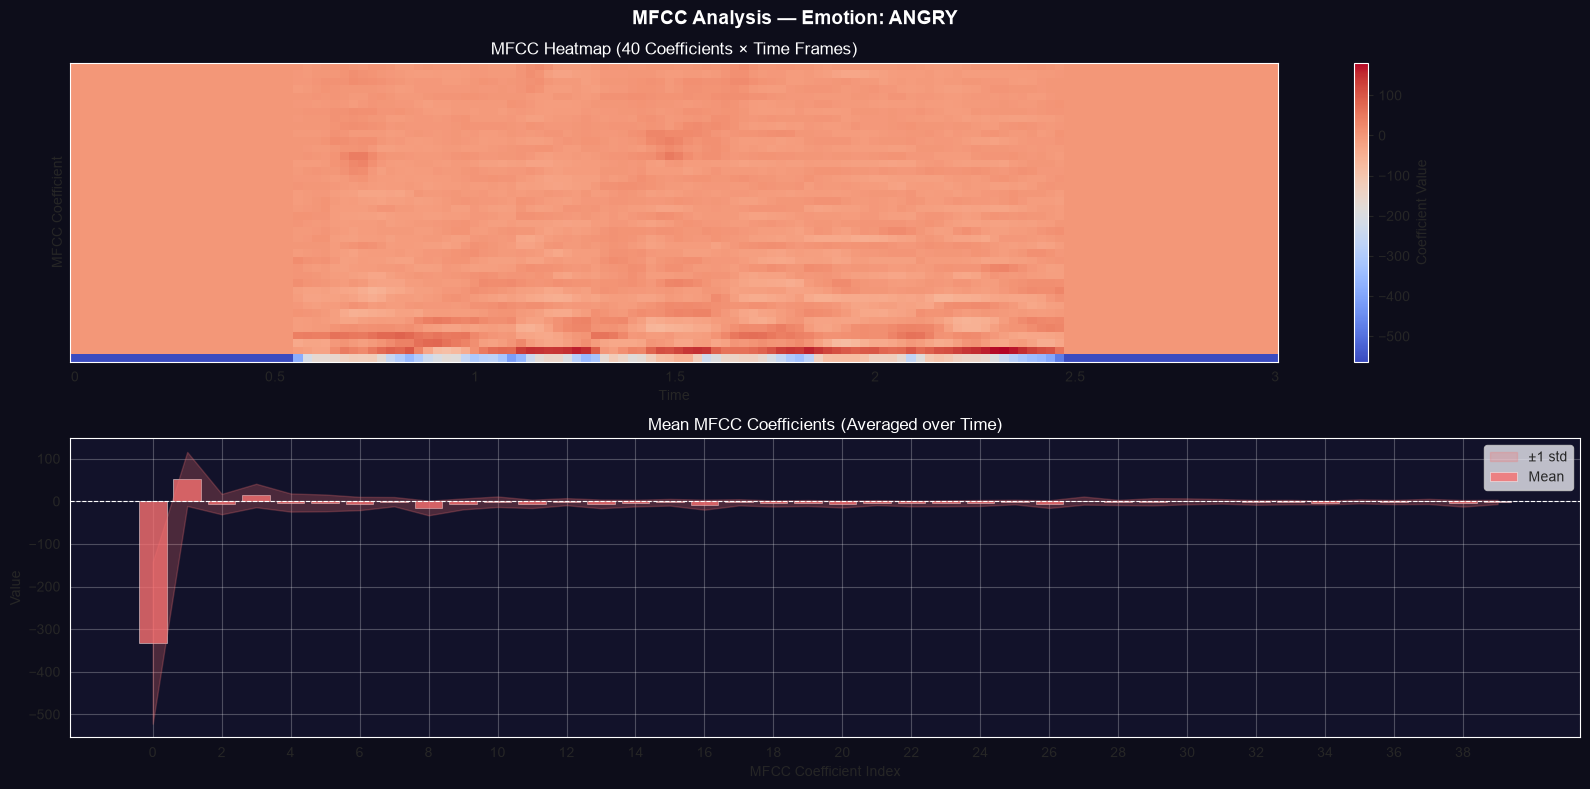

✅ Saved → C:\Speech Emotion Recognition\notebooks\..\reports\spectrograms\mfcc_demo_angry.png


In [2]:
demo_idx   = np.where(y == EMOTIONS.index('angry'))[0][0]
demo_sig   = X[demo_idx]
demo_label = EMOTIONS[y[demo_idx]]

# Compute MFCC
mfcc = librosa.feature.mfcc(y=demo_sig, sr=SR, n_mfcc=N_MFCC,
                             n_fft=N_FFT, hop_length=HOP_LENGTH)

fig, axes = plt.subplots(2, 1, figsize=(16, 8))
fig.patch.set_facecolor(DARK_BG)
fig.suptitle(f'MFCC Analysis — Emotion: {demo_label.upper()}',
             fontsize=14, fontweight='bold', color='white')

# ── Spectrogram heatmap ───────────────────────────────────────────────────
ax1 = axes[0]
ax1.set_facecolor(PANEL_BG)
img = librosa.display.specshow(mfcc, sr=SR, x_axis='time', hop_length=HOP_LENGTH,
                               ax=ax1, cmap='coolwarm')
ax1.set_ylabel('MFCC Coefficient')
ax1.set_title('MFCC Heatmap (40 Coefficients × Time Frames)', color='white')
fig.colorbar(img, ax=ax1, label='Coefficient Value')

# ── Mean MFCC bar chart ───────────────────────────────────────────────────
ax2 = axes[1]
ax2.set_facecolor(PANEL_BG)
mfcc_means = mfcc.mean(axis=1)
mfcc_stds  = mfcc.std(axis=1)
x          = np.arange(N_MFCC)
ax2.bar(x, mfcc_means, color='#f87171', alpha=0.8, label='Mean',
        edgecolor='white', linewidth=0.4)
ax2.fill_between(x, mfcc_means - mfcc_stds, mfcc_means + mfcc_stds,
                 color='#f87171', alpha=0.25, label='±1 std')
ax2.axhline(0, color='white', linewidth=0.8, linestyle='--')
ax2.set_xlabel('MFCC Coefficient Index')
ax2.set_ylabel('Value')
ax2.set_title('Mean MFCC Coefficients (Averaged over Time)', color='white')
ax2.set_xticks(x[::2])
ax2.legend(fontsize=10)
ax2.grid(alpha=0.25)

plt.tight_layout()
path = os.path.join(SPECREP, 'mfcc_demo_angry.png')
plt.savefig(path, dpi=150, bbox_inches='tight', facecolor=DARK_BG)
plt.show()
print(f'✅ Saved → {path}')

## 6.4 — MFCC Comparison Across All 8 Emotions

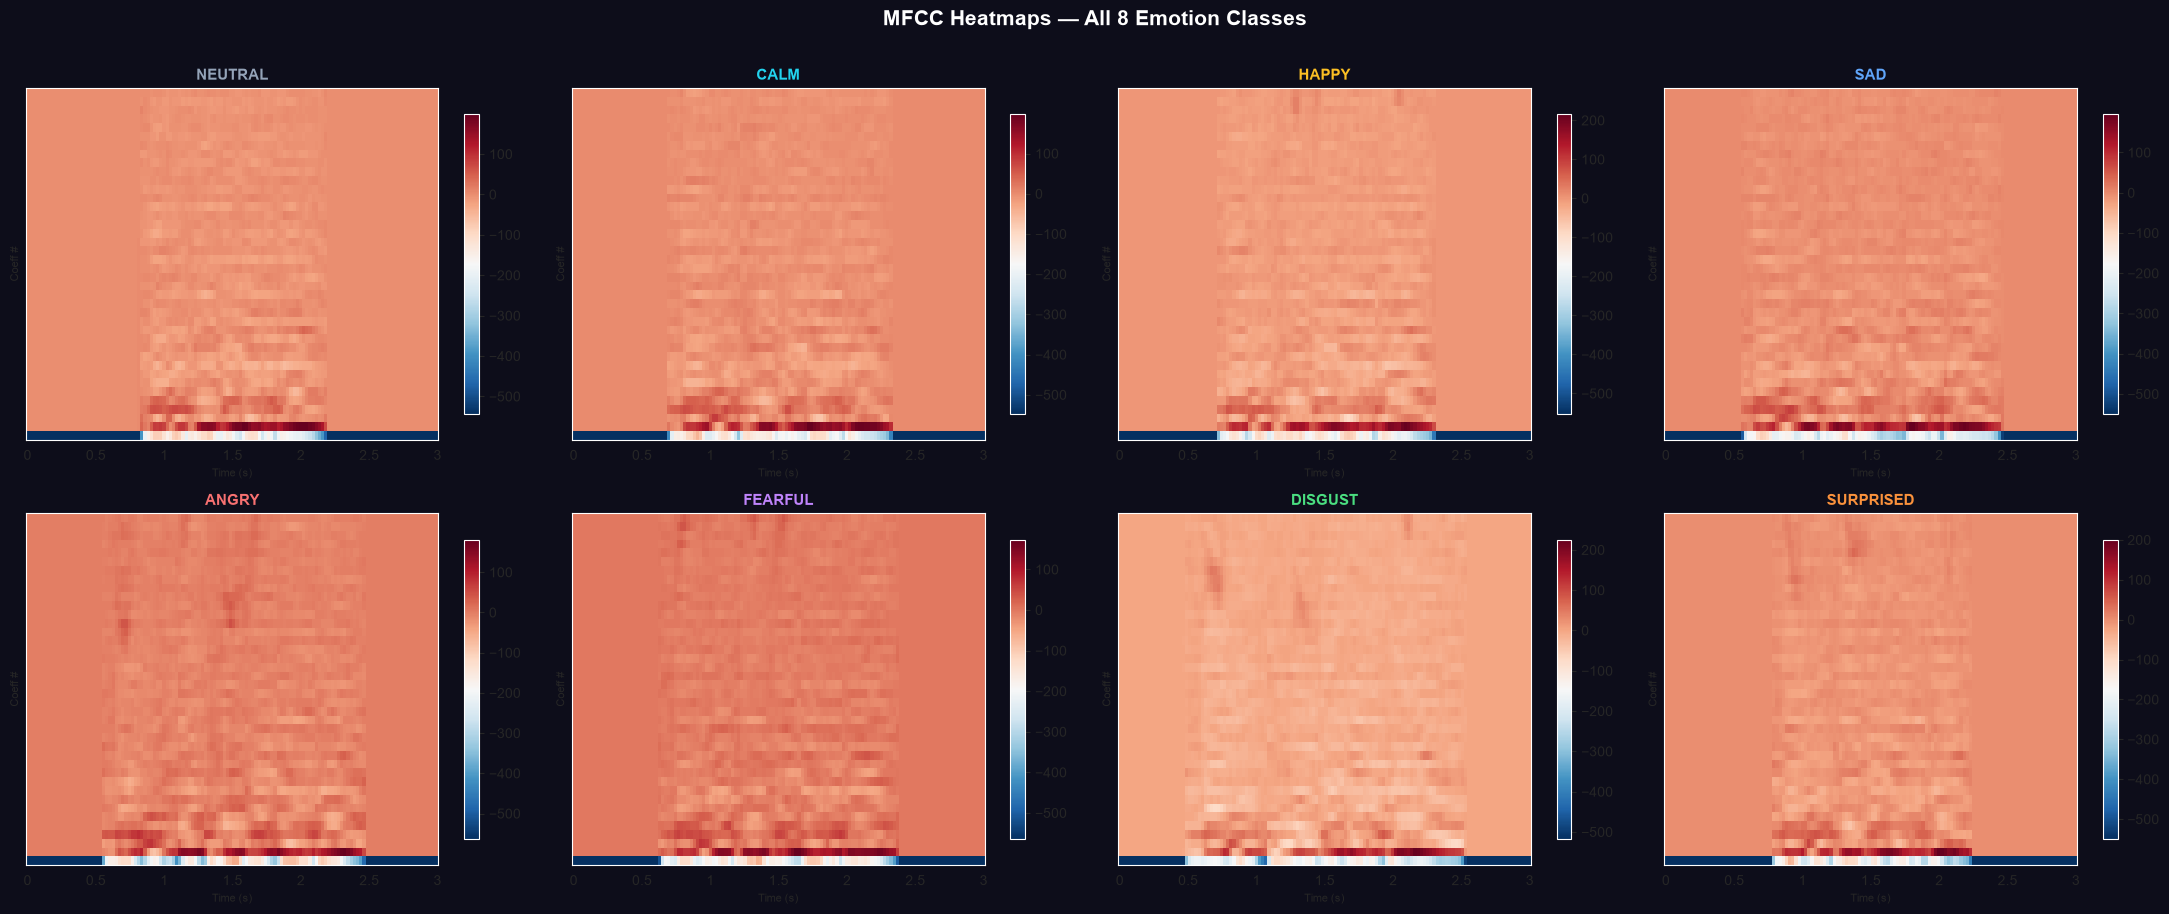

✅ Saved → C:\Speech Emotion Recognition\notebooks\..\reports\spectrograms\mfcc_gallery_all_emotions.png


In [3]:
fig, axes = plt.subplots(2, 4, figsize=(22, 9))
fig.patch.set_facecolor(DARK_BG)
fig.suptitle('MFCC Heatmaps — All 8 Emotion Classes',
             fontsize=15, fontweight='bold', color='white', y=1.01)

for ax, emotion in zip(axes.flat, EMOTIONS):
    idx   = np.where(y == EMOTIONS.index(emotion))[0][0]
    sig   = X[idx]
    color = ECOLORS[emotion]

    mfcc_e = librosa.feature.mfcc(y=sig, sr=SR, n_mfcc=N_MFCC,
                                   n_fft=N_FFT, hop_length=HOP_LENGTH)
    ax.set_facecolor(PANEL_BG)
    img = librosa.display.specshow(mfcc_e, sr=SR, x_axis='time',
                                   hop_length=HOP_LENGTH, ax=ax, cmap='RdBu_r')
    ax.set_title(emotion.upper(), color=color, fontweight='bold', fontsize=11)
    ax.set_xlabel('Time (s)', fontsize=8)
    ax.set_ylabel('Coeff #', fontsize=8)
    fig.colorbar(img, ax=ax, shrink=0.85)

plt.tight_layout()
path = os.path.join(SPECREP, 'mfcc_gallery_all_emotions.png')
plt.savefig(path, dpi=150, bbox_inches='tight', facecolor=DARK_BG)
plt.show()
print(f'✅ Saved → {path}')

## 6.5 — Mel Spectrogram Feature Visualisation

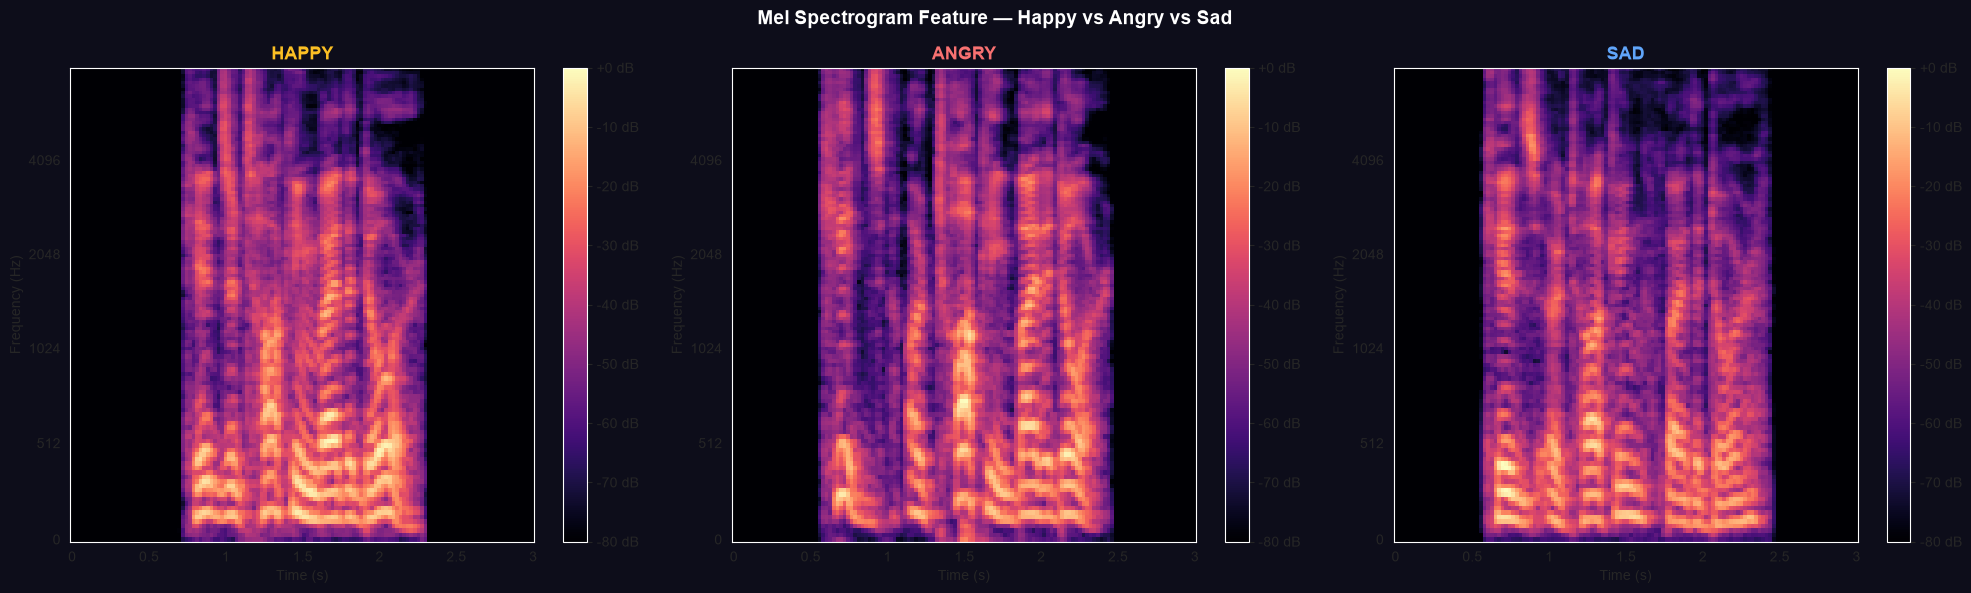

✅ Saved → C:\Speech Emotion Recognition\notebooks\..\reports\spectrograms\mel_spectrogram_comparison.png


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.patch.set_facecolor(DARK_BG)
fig.suptitle('Mel Spectrogram Feature — Happy vs Angry vs Sad',
             fontsize=14, fontweight='bold', color='white')

for ax, em in zip(axes, ['happy', 'angry', 'sad']):
    idx = np.where(y == EMOTIONS.index(em))[0][0]
    sig = X[idx]
    S   = librosa.feature.melspectrogram(y=sig, sr=SR, n_mels=N_MELS,
                                         fmax=FMAX, n_fft=N_FFT, hop_length=HOP_LENGTH)
    S_db = librosa.power_to_db(S, ref=np.max)
    ax.set_facecolor(PANEL_BG)
    img = librosa.display.specshow(S_db, sr=SR, x_axis='time', y_axis='mel',
                                   fmax=FMAX, ax=ax, cmap='magma')
    ax.set_title(em.upper(), color=ECOLORS[em], fontweight='bold', fontsize=13)
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Frequency (Hz)')
    fig.colorbar(img, ax=ax, format='%+2.0f dB')

plt.tight_layout()
path = os.path.join(SPECREP, 'mel_spectrogram_comparison.png')
plt.savefig(path, dpi=150, bbox_inches='tight', facecolor=DARK_BG)
plt.show()
print(f'✅ Saved → {path}')

## 6.6 — Chroma, ZCR & Spectral Features (Side-by-Side)

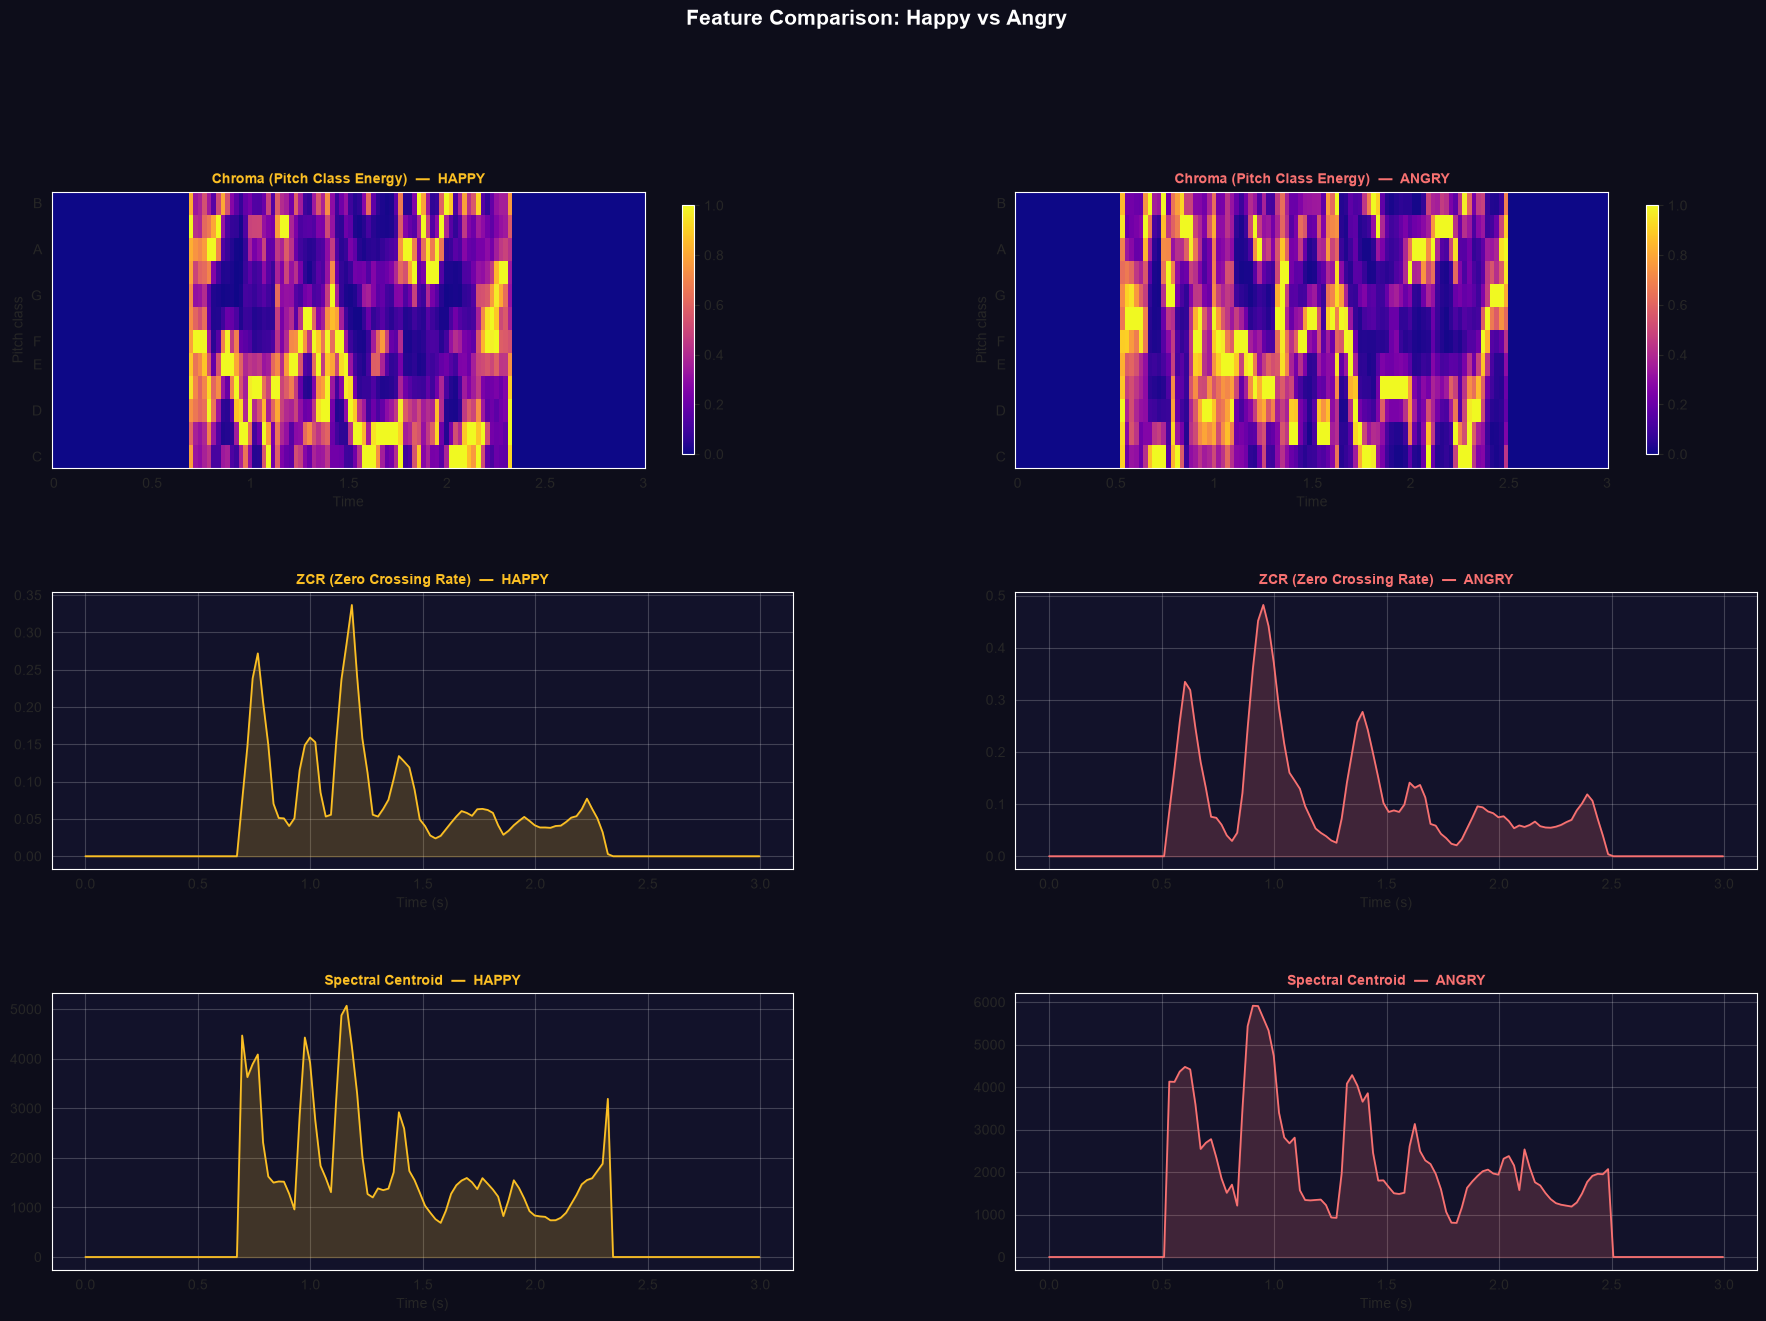

✅ Saved → C:\Speech Emotion Recognition\notebooks\..\reports\spectrograms\chroma_zcr_spectral_comparison.png


In [5]:
sig_happy, _ = X[np.where(y==EMOTIONS.index('happy'))[0][0]], None
sig_angry, _ = X[np.where(y==EMOTIONS.index('angry'))[0][0]], None

fig = plt.figure(figsize=(22, 14))
fig.patch.set_facecolor(DARK_BG)
fig.suptitle('Feature Comparison: Happy vs Angry',
             fontsize=15, fontweight='bold', color='white', y=1.01)
gs  = gridspec.GridSpec(3, 2, hspace=0.45, wspace=0.3)

pairs = [
    (sig_happy, sig_angry, 'Chroma (Pitch Class Energy)',
     lambda s: librosa.feature.chroma_stft(y=s, sr=SR, n_fft=N_FFT, hop_length=HOP_LENGTH),
     'chroma', 0),
    (sig_happy, sig_angry, 'ZCR (Zero Crossing Rate)',
     lambda s: librosa.feature.zero_crossing_rate(s, hop_length=HOP_LENGTH),
     'linear', 1),
    (sig_happy, sig_angry, 'Spectral Centroid',
     lambda s: librosa.feature.spectral_centroid(y=s, sr=SR, hop_length=HOP_LENGTH),
     'linear', 2),
]

for (sig_h, sig_a, title, fn, y_axis, row) in pairs:
    for col, (sig, em) in enumerate([(sig_h, 'happy'), (sig_a, 'angry')]):
        ax = fig.add_subplot(gs[row, col])
        ax.set_facecolor(PANEL_BG)
        feat = fn(sig)
        if y_axis in ('chroma',):
            img = librosa.display.specshow(feat, sr=SR, x_axis='time',
                                           y_axis=y_axis, hop_length=HOP_LENGTH,
                                           ax=ax, cmap='plasma')
            fig.colorbar(img, ax=ax, shrink=0.9)
        else:
            t = librosa.frames_to_time(np.arange(feat.shape[1]), sr=SR, hop_length=HOP_LENGTH)
            ax.plot(t, feat[0], color=ECOLORS[em], linewidth=1.3)
            ax.fill_between(t, feat[0], alpha=0.2, color=ECOLORS[em])
            ax.set_xlabel('Time (s)')
        ax.set_title(f'{title}  —  {em.upper()}', color=ECOLORS[em],
                     fontsize=10, fontweight='bold')
        ax.grid(alpha=0.2)

path = os.path.join(SPECREP, 'chroma_zcr_spectral_comparison.png')
plt.savefig(path, dpi=150, bbox_inches='tight', facecolor=DARK_BG)
plt.show()
print(f'✅ Saved → {path}')

## 6.7 — Full Feature Extraction Function

In [6]:
def extract_features(signal: np.ndarray, sr: int = SR,
                     n_mfcc: int = N_MFCC, n_mels: int = N_MELS,
                     n_chroma: int = N_CHROMA, n_fft: int = N_FFT,
                     hop_length: int = HOP_LENGTH, fmax: int = FMAX) -> np.ndarray:
    """
    Extract a combined feature vector from a single preprocessed audio signal.

    Features extracted (all averaged over time frames):
      - MFCC          : n_mfcc values  (default 40)
      - MFCC delta    : n_mfcc values  (1st derivative)
      - MFCC delta2   : n_mfcc values  (2nd derivative)
      - Mel Spectrogram : n_mels values (default 128)
      - Chroma        : n_chroma values (default 12)
      - ZCR           : 1 value
      - Spectral Centroid   : 1 value
      - Spectral Bandwidth  : 1 value
      - Spectral Rolloff    : 1 value

    Total: 40 + 40 + 40 + 128 + 12 + 1 + 1 + 1 + 1 = 264 features

    Returns
    -------
    np.ndarray of shape (264,)
    """
    # ── MFCC + deltas ──────────────────────────────────────────────────────
    mfcc    = librosa.feature.mfcc(y=signal, sr=sr, n_mfcc=n_mfcc,
                                   n_fft=n_fft, hop_length=hop_length)
    mfcc_d  = librosa.feature.delta(mfcc)
    mfcc_d2 = librosa.feature.delta(mfcc, order=2)
    f_mfcc  = np.concatenate([
        mfcc.mean(axis=1), mfcc_d.mean(axis=1), mfcc_d2.mean(axis=1)
    ])  # 120

    # ── Mel Spectrogram ────────────────────────────────────────────────────
    mel   = librosa.feature.melspectrogram(y=signal, sr=sr, n_mels=n_mels,
                                           fmax=fmax, n_fft=n_fft, hop_length=hop_length)
    mel_db = librosa.power_to_db(mel, ref=np.max)
    f_mel  = mel_db.mean(axis=1)  # 128

    # ── Chroma ────────────────────────────────────────────────────────────
    chroma = librosa.feature.chroma_stft(y=signal, sr=sr, n_chroma=n_chroma,
                                          n_fft=n_fft, hop_length=hop_length)
    f_chroma = chroma.mean(axis=1)  # 12

    # ── Scalar features ────────────────────────────────────────────────────
    zcr       = librosa.feature.zero_crossing_rate(signal, hop_length=hop_length)
    sc        = librosa.feature.spectral_centroid(y=signal, sr=sr, hop_length=hop_length)
    sb        = librosa.feature.spectral_bandwidth(y=signal, sr=sr, hop_length=hop_length)
    rolloff   = librosa.feature.spectral_rolloff(y=signal, sr=sr, hop_length=hop_length,
                                                  roll_percent=0.85)
    f_scalar  = np.array([
        float(zcr.mean()),
        float(sc.mean()),
        float(sb.mean()),
        float(rolloff.mean())
    ])  # 4

    # ── Concatenate all ───────────────────────────────────────────────────
    return np.concatenate([f_mfcc, f_mel, f_chroma, f_scalar]).astype(np.float32)


# Test on one clip
test_vec = extract_features(X[0])
print('✅ Feature extraction function verified!')
print(f'   Feature vector length : {len(test_vec)}')
print(f'   Breakdown:')
print(f'     MFCC (×3 incl. deltas) : {N_MFCC * 3}  (indices 0–{N_MFCC*3-1})')
print(f'     Mel Spectrogram         : {N_MELS}  (indices {N_MFCC*3}–{N_MFCC*3+N_MELS-1})')
print(f'     Chroma                  : {N_CHROMA}  (indices {N_MFCC*3+N_MELS}–{N_MFCC*3+N_MELS+N_CHROMA-1})')
print(f'     Scalar (ZCR,SC,SB,RO)  : 4')
print(f'   Min : {test_vec.min():.4f}  Max : {test_vec.max():.4f}  NaN: {np.isnan(test_vec).sum()}')

✅ Feature extraction function verified!
   Feature vector length : 264
   Breakdown:
     MFCC (×3 incl. deltas) : 120  (indices 0–119)
     Mel Spectrogram         : 128  (indices 120–247)
     Chroma                  : 12  (indices 248–259)
     Scalar (ZCR,SC,SB,RO)  : 4
   Min : -376.6315  Max : 1589.7301  NaN: 0


## 6.8 — Batch Feature Extraction (All 1,440 Clips)

In [7]:
print(f'🚀 Extracting features from {N_CLIPS} clips...')
print(f'   This will take ~3–5 minutes on CPU.\n')

t0          = time.time()
feature_list = []
failed_idx   = []

for i in tqdm(range(N_CLIPS), desc='Extracting Features'):
    try:
        fv = extract_features(X[i])
        feature_list.append(fv)
    except Exception as e:
        print(f'  ❌ Clip {i}: {e}')
        feature_list.append(np.zeros(len(test_vec), dtype=np.float32))
        failed_idx.append(i)

X_features = np.array(feature_list, dtype=np.float32)  # (1440, 264)
elapsed    = time.time() - t0

print(f'\n✅ Feature extraction complete!')
print(f'   Elapsed time    : {elapsed:.1f}s  ({elapsed/N_CLIPS*1000:.0f}ms/clip)')
print(f'   Feature matrix  : {X_features.shape}  (clips × features)')
print(f'   Memory          : {X_features.nbytes/1024**2:.1f} MB')
print(f'   Failed clips    : {len(failed_idx)}')
print(f'   NaN values      : {np.isnan(X_features).sum()}')
print(f'   Inf values      : {np.isinf(X_features).sum()}')

🚀 Extracting features from 1440 clips...
   This will take ~3–5 minutes on CPU.



Extracting Features:   0%|          | 0/1440 [00:00<?, ?it/s]


✅ Feature extraction complete!
   Elapsed time    : 65.9s  (46ms/clip)
   Feature matrix  : (1440, 264)  (clips × features)
   Memory          : 1.5 MB
   Failed clips    : 0
   NaN values      : 0
   Inf values      : 0


## 6.9 — Generate Feature Column Names

In [8]:
feature_names = (
    [f'mfcc_{i+1}'      for i in range(N_MFCC)]   +   # 40 MFCC
    [f'mfcc_d_{i+1}'    for i in range(N_MFCC)]   +   # 40 MFCC delta
    [f'mfcc_d2_{i+1}'   for i in range(N_MFCC)]   +   # 40 MFCC delta2
    [f'mel_{i+1}'       for i in range(N_MELS)]   +   # 128 Mel
    [f'chroma_{i+1}'    for i in range(N_CHROMA)] +   # 12 Chroma
    ['zcr', 'spectral_centroid', 'spectral_bandwidth', 'spectral_rolloff']  # 4 scalars
)

assert len(feature_names) == X_features.shape[1], \
    f'Mismatch: {len(feature_names)} names vs {X_features.shape[1]} features'

print(f'✅ Feature names verified: {len(feature_names)} total')
print(f'   First 5  : {feature_names[:5]}')
print(f'   Last 5   : {feature_names[-5:]}')
print(f'   Feature groups:')
print(f'     MFCC        : {feature_names[:40][-1]}  (1–40)')
print(f'     MFCC delta  : mfcc_d_1–mfcc_d_40  (41–80)')
print(f'     MFCC delta2 : mfcc_d2_1–mfcc_d2_40  (81–120)')
print(f'     Mel         : mel_1–mel_128  (121–248)')
print(f'     Chroma      : chroma_1–chroma_12  (249–260)')
print(f'     Scalar      : zcr, sc, sb, rolloff  (261–264)')

✅ Feature names verified: 264 total
   First 5  : ['mfcc_1', 'mfcc_2', 'mfcc_3', 'mfcc_4', 'mfcc_5']
   Last 5   : ['chroma_12', 'zcr', 'spectral_centroid', 'spectral_bandwidth', 'spectral_rolloff']
   Feature groups:
     MFCC        : mfcc_40  (1–40)
     MFCC delta  : mfcc_d_1–mfcc_d_40  (41–80)
     MFCC delta2 : mfcc_d2_1–mfcc_d2_40  (81–120)
     Mel         : mel_1–mel_128  (121–248)
     Chroma      : chroma_1–chroma_12  (249–260)
     Scalar      : zcr, sc, sb, rolloff  (261–264)


## 6.10 — Build & Save the Final Feature Dataset

In [9]:
# Build feature DataFrame
feat_df               = pd.DataFrame(X_features, columns=feature_names)
feat_df['emotion']    = [EMOTIONS[i] for i in y]
feat_df['label']      = y
feat_df['actor']      = df['actor'].values
feat_df['gender']     = df['gender'].values
feat_df['intensity']  = df['intensity'].values
feat_df['filename']   = df['filename'].values

# Save
csv_path = os.path.join(FEATURES, 'features_dataset.csv')
npy_path = os.path.join(DATA_PROC, 'X_features.npy')

feat_df.to_csv(csv_path, index=False)
np.save(npy_path, X_features)

print('✅ Feature dataset saved!')
print(f'   CSV  : {csv_path}  ({os.path.getsize(csv_path)/1024**2:.1f} MB)')
print(f'   NPY  : {npy_path}  ({os.path.getsize(npy_path)/1024/1024:.1f} MB)')
print(f'   Shape: {feat_df.shape}')
print()
print('📋 Dataset preview:')
feat_df[['filename','emotion','label','actor','gender'] + feature_names[:5]].head(5)

✅ Feature dataset saved!
   CSV  : C:\Speech Emotion Recognition\notebooks\..\features\features_dataset.csv  (4.0 MB)
   NPY  : C:\Speech Emotion Recognition\notebooks\..\data\processed\X_features.npy  (1.5 MB)
   Shape: (1440, 270)

📋 Dataset preview:


,filename,emotion,label,actor,gender,mfcc_1,mfcc_2,mfcc_3,mfcc_4,mfcc_5
0,03-01-01-01-01-01-01.wav,neutral,0,1,male,-376.631531,56.560638,-4.105415,11.032596,6.552364
1,03-01-01-01-01-02-01.wav,neutral,0,1,male,-385.705505,53.263054,-3.711738,13.491071,6.395794
2,03-01-01-01-02-01-01.wav,neutral,0,1,male,-407.745117,55.953777,-2.798040,12.172185,3.057290
3,03-01-01-01-02-02-01.wav,neutral,0,1,male,-414.088348,48.861134,0.082631,11.892365,4.273141
4,03-01-02-01-01-01-01.wav,calm,1,1,male,-347.971924,62.736454,-0.140264,14.709029,6.546796


## 6.11 — Feature Distribution Analysis

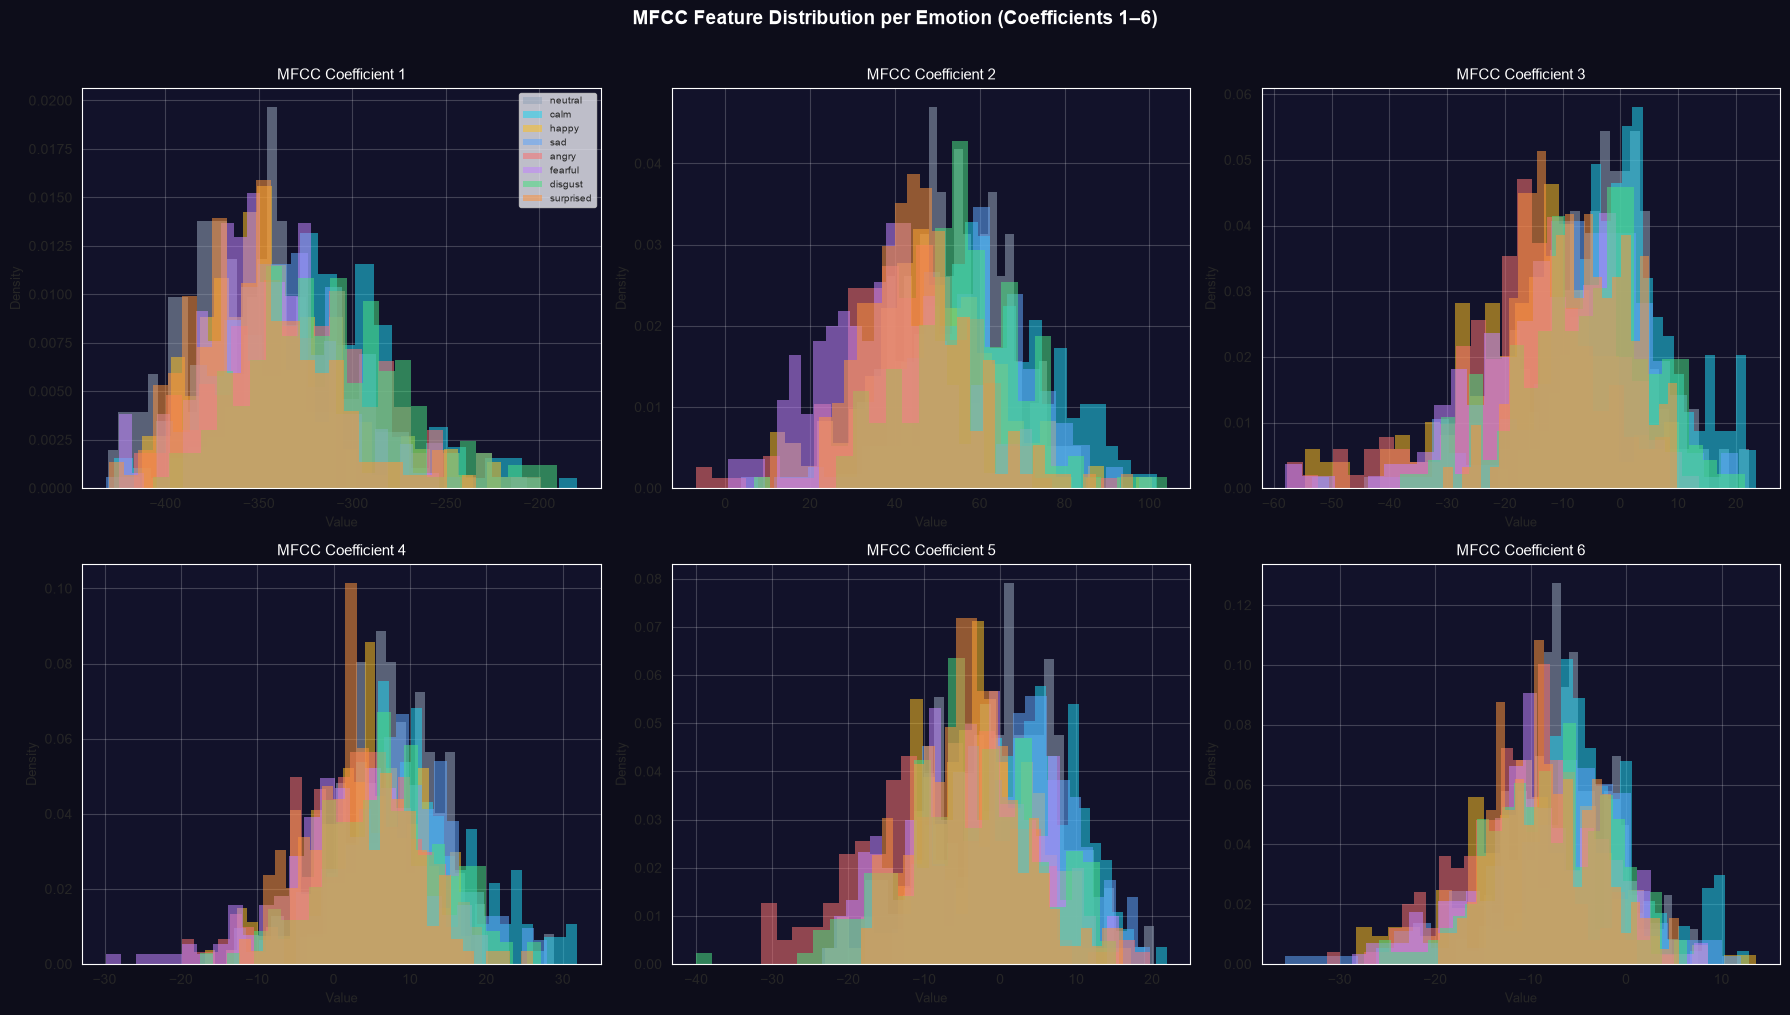

✅ Saved → C:\Speech Emotion Recognition\notebooks\..\reports\spectrograms\mfcc_distribution_per_emotion.png


In [10]:
# ── Distribution of first 6 MFCC coefficients across emotions ─────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.patch.set_facecolor(DARK_BG)
fig.suptitle('MFCC Feature Distribution per Emotion (Coefficients 1–6)',
             fontsize=14, fontweight='bold', color='white', y=1.01)

for ax, coeff_idx in zip(axes.flat, range(1, 7)):
    col   = f'mfcc_{coeff_idx}'
    ax.set_facecolor(PANEL_BG)
    for em in EMOTIONS:
        vals = feat_df[feat_df['emotion'] == em][col].values
        ax.hist(vals, bins=25, alpha=0.55, color=ECOLORS[em],
                label=em, edgecolor='none', density=True)
    ax.set_title(f'MFCC Coefficient {coeff_idx}', color='white', fontsize=11)
    ax.set_xlabel('Value', fontsize=9)
    ax.set_ylabel('Density', fontsize=9)
    ax.grid(alpha=0.2)
    if coeff_idx == 1:
        ax.legend(fontsize=7, loc='upper right')

plt.tight_layout()
path = os.path.join(SPECREP, 'mfcc_distribution_per_emotion.png')
plt.savefig(path, dpi=150, bbox_inches='tight', facecolor=DARK_BG)
plt.show()
print(f'✅ Saved → {path}')

## 6.12 — Feature Correlation Heatmap (Top Features)

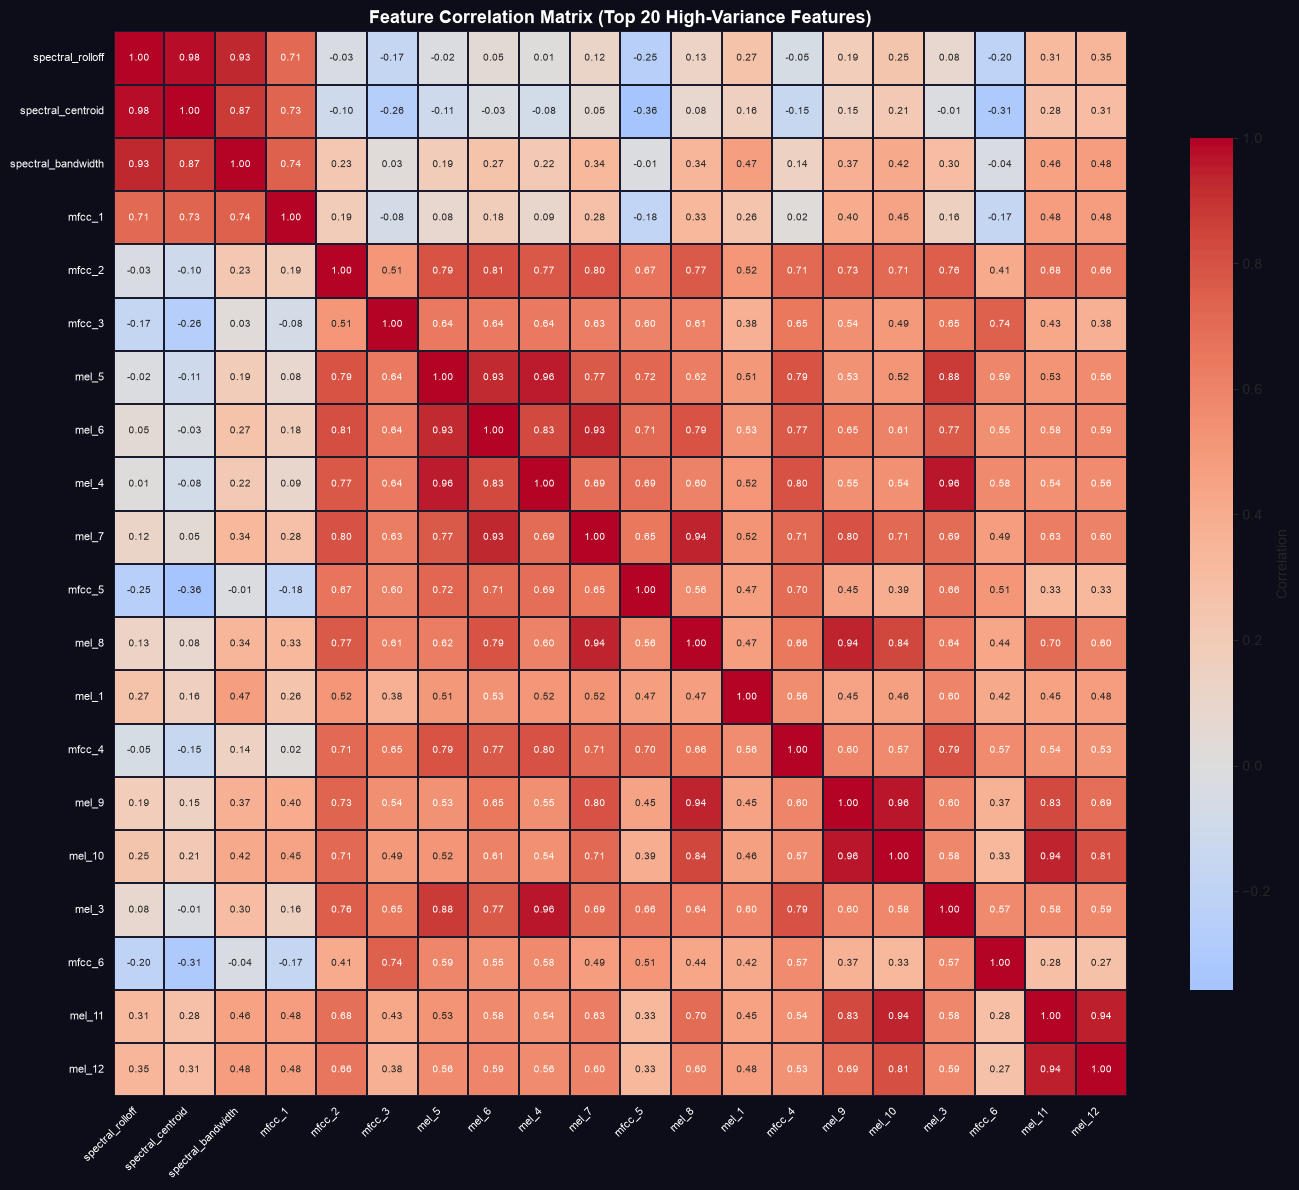

✅ Saved → C:\Speech Emotion Recognition\notebooks\..\reports\spectrograms\feature_correlation_heatmap.png


In [11]:
# Select top 20 most discriminative features (by variance)
feat_only = feat_df[feature_names]
top_cols  = feat_only.var().nlargest(20).index.tolist()
corr_mat  = feat_df[top_cols].corr()

fig, ax = plt.subplots(figsize=(14, 12))
fig.patch.set_facecolor(DARK_BG)
ax.set_facecolor(PANEL_BG)

sns.heatmap(corr_mat, ax=ax, cmap='coolwarm', center=0,
            annot=True, fmt='.2f', annot_kws={'size': 7},
            linewidths=0.3, linecolor='#1a1a2e',
            cbar_kws={'label': 'Correlation', 'shrink': 0.8})
ax.set_title('Feature Correlation Matrix (Top 20 High-Variance Features)',
             color='white', fontsize=13, fontweight='bold')
ax.tick_params(colors='white', labelsize=8)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', color='white')
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, color='white')

plt.tight_layout()
path = os.path.join(SPECREP, 'feature_correlation_heatmap.png')
plt.savefig(path, dpi=150, bbox_inches='tight', facecolor=DARK_BG)
plt.show()
print(f'✅ Saved → {path}')

## 6.13 — Mean Feature Profile per Emotion (Radar / Bar)

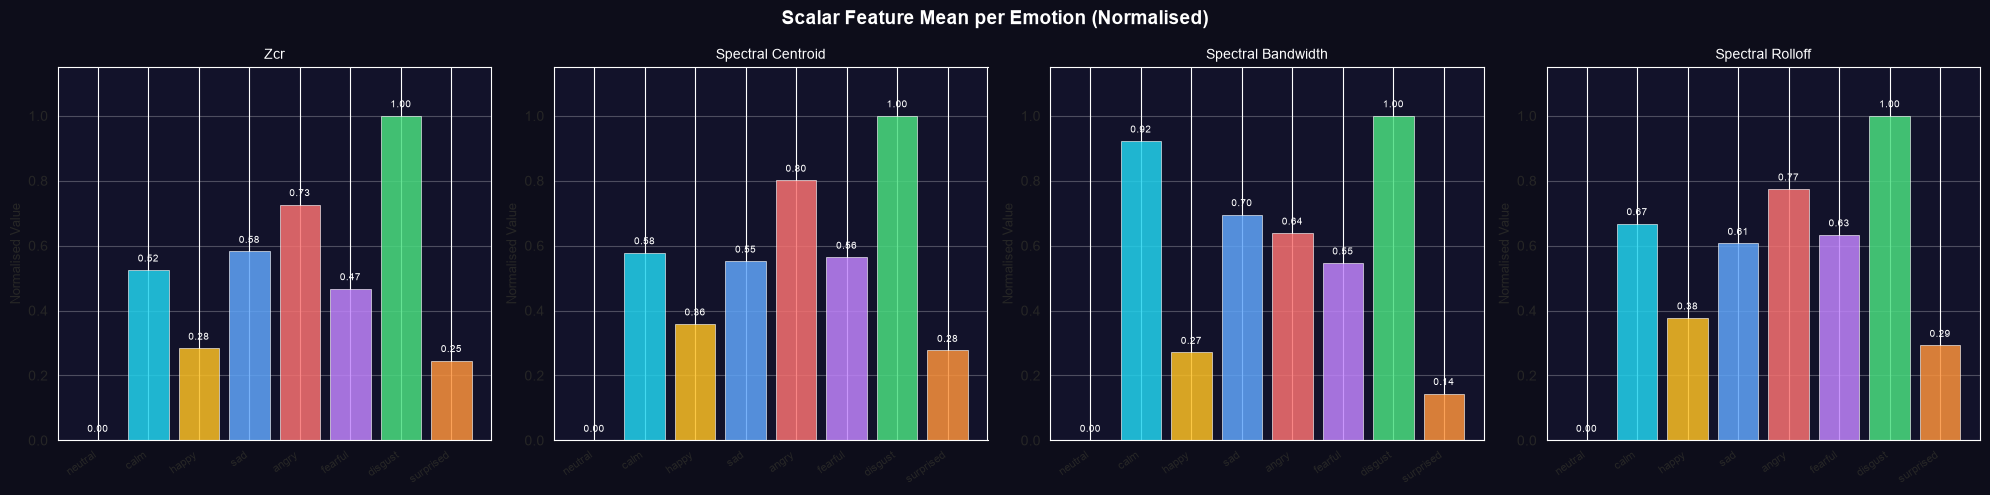

✅ Saved → C:\Speech Emotion Recognition\notebooks\..\reports\spectrograms\scalar_features_per_emotion.png


In [12]:
# Scalar features comparison across emotions
scalar_feats = ['zcr', 'spectral_centroid', 'spectral_bandwidth', 'spectral_rolloff']
scalar_df    = feat_df.groupby('emotion')[scalar_feats].mean().reindex(EMOTIONS)

# Normalise each scalar 0–1 for clean comparison
norm_scalar = (scalar_df - scalar_df.min()) / (scalar_df.max() - scalar_df.min())

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.patch.set_facecolor(DARK_BG)
fig.suptitle('Scalar Feature Mean per Emotion (Normalised)',
             fontsize=14, fontweight='bold', color='white')

for ax, feat in zip(axes, scalar_feats):
    ax.set_facecolor(PANEL_BG)
    colors_ = [ECOLORS[e] for e in EMOTIONS]
    vals    = norm_scalar[feat].values
    bars    = ax.bar(EMOTIONS, vals, color=colors_, alpha=0.85,
                     edgecolor='white', linewidth=0.5)
    ax.set_xticklabels(EMOTIONS, rotation=35, ha='right', fontsize=8)
    ax.set_ylabel('Normalised Value', fontsize=9)
    ax.set_title(feat.replace('_', ' ').title(), color='white', fontsize=10)
    ax.grid(axis='y', alpha=0.25)
    ax.set_ylim([0, 1.15])
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f'{val:.2f}', ha='center', va='bottom', fontsize=7, color='white')

plt.tight_layout()
path = os.path.join(SPECREP, 'scalar_features_per_emotion.png')
plt.savefig(path, dpi=150, bbox_inches='tight', facecolor=DARK_BG)
plt.show()
print(f'✅ Saved → {path}')

## 6.14 — Mean MFCC Profile per Emotion

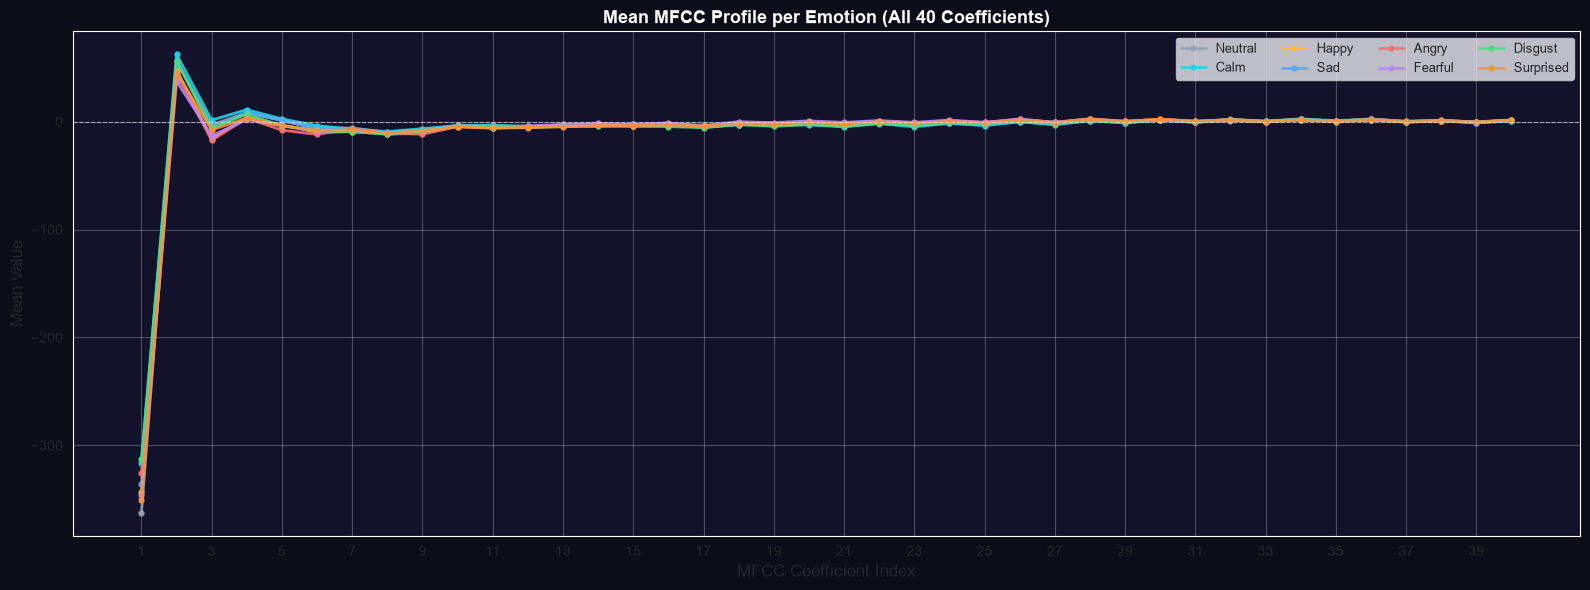

✅ Saved → C:\Speech Emotion Recognition\notebooks\..\reports\spectrograms\mean_mfcc_profile_per_emotion.png


In [13]:
mfcc_cols  = [f'mfcc_{i}' for i in range(1, N_MFCC+1)]
mfcc_by_em = feat_df.groupby('emotion')[mfcc_cols].mean().reindex(EMOTIONS)

fig, ax = plt.subplots(figsize=(16, 6))
fig.patch.set_facecolor(DARK_BG)
ax.set_facecolor(PANEL_BG)

x = np.arange(1, N_MFCC + 1)
for em in EMOTIONS:
    ax.plot(x, mfcc_by_em.loc[em].values, color=ECOLORS[em],
            linewidth=2.0, marker='o', markersize=3.5,
            alpha=0.9, label=em.capitalize())

ax.axhline(0, color='white', linewidth=0.8, linestyle='--', alpha=0.5)
ax.set_xlabel('MFCC Coefficient Index', fontsize=12)
ax.set_ylabel('Mean Value', fontsize=12)
ax.set_title('Mean MFCC Profile per Emotion (All 40 Coefficients)',
             fontsize=13, color='white', fontweight='bold')
ax.set_xticks(x[::2])
ax.legend(ncol=4, fontsize=9, loc='upper right')
ax.grid(alpha=0.25)

plt.tight_layout()
path = os.path.join(SPECREP, 'mean_mfcc_profile_per_emotion.png')
plt.savefig(path, dpi=150, bbox_inches='tight', facecolor=DARK_BG)
plt.show()
print(f'✅ Saved → {path}')

## 6.15 — Final Dataset Verification

In [14]:
# Reload from disk to confirm integrity
X_feat_check = np.load(os.path.join(DATA_PROC, 'X_features.npy'))
df_check     = pd.read_csv(os.path.join(FEATURES, 'features_dataset.csv'))

print('=' * 60)
print('     MODULE 6 — FINAL VERIFICATION REPORT')
print('=' * 60)
print(f'  X_features shape  : {X_feat_check.shape}')
print(f'  CSV rows×cols     : {df_check.shape}')
print(f'  NaN count         : {np.isnan(X_feat_check).sum()}')
print(f'  Inf count         : {np.isinf(X_feat_check).sum()}')
print(f'  Feature range     : [{X_feat_check.min():.3f}, {X_feat_check.max():.3f}]')
print()
print('  Samples per emotion:')
for em in EMOTIONS:
    cnt = int((df_check['emotion'] == em).sum())
    bar = '█' * (cnt // 12)
    print(f'    {em:<10}  {cnt:>4}  {bar}')
print()
print(f'  Feature columns: {len(feature_names)}')
print(f'    MFCC + deltas : {N_MFCC * 3}')
print(f'    Mel           : {N_MELS}')
print(f'    Chroma        : {N_CHROMA}')
print(f'    Scalars       : 4')
print('=' * 60)
print('  STATUS: Module 6 COMPLETE ✅')
print('=' * 60)

     MODULE 6 — FINAL VERIFICATION REPORT
  X_features shape  : (1440, 264)
  CSV rows×cols     : (1440, 270)
  NaN count         : 0
  Inf count         : 0
  Feature range     : [-431.849, 6167.938]

  Samples per emotion:
    neutral       96  ████████
    calm         192  ████████████████
    happy        192  ████████████████
    sad          192  ████████████████
    angry        192  ████████████████
    fearful      192  ████████████████
    disgust      192  ████████████████
    surprised    192  ████████████████

  Feature columns: 264
    MFCC + deltas : 120
    Mel           : 128
    Chroma        : 12
    Scalars       : 4
  STATUS: Module 6 COMPLETE ✅


## 6.16 — Module 6 Summary

| Feature Group | Dimensions | Extraction Method |
|---|---|---|
| **MFCC** | 40 | `librosa.feature.mfcc`, mean over frames |
| **MFCC Δ (delta)** | 40 | `librosa.feature.delta`, mean over frames |
| **MFCC Δ² (delta2)** | 40 | `librosa.feature.delta(order=2)`, mean |
| **Mel Spectrogram** | 128 | `librosa.feature.melspectrogram` (dB), mean |
| **Chroma** | 12 | `librosa.feature.chroma_stft`, mean |
| **ZCR** | 1 | `librosa.feature.zero_crossing_rate`, mean |
| **Spectral Centroid** | 1 | `librosa.feature.spectral_centroid`, mean |
| **Spectral Bandwidth** | 1 | `librosa.feature.spectral_bandwidth`, mean |
| **Spectral Rolloff** | 1 | `librosa.feature.spectral_rolloff`, mean |
| **TOTAL** | **264** | |

### Saved Output Files
| File | Description |
|---|---|
| `features/features_dataset.csv` | Full (1440 × 264+metadata) feature CSV |
| `data/processed/X_features.npy` | (1440, 264) float32 NumPy array |
| 6 spectrogram PNGs | In `reports/spectrograms/` |

✅ **Module 6 Complete — Ready for Module 7: ML Classification**